# 05_统计检验方法-T检验

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家详细聊聊**T检验**！\~

T检验（t-test）是统计学中一种用于比较两个数据集均值是否有显著差异的检验方法，尤其适用于样本较小且未知总体标准差的情况。

它的应用场景主要是在以下两种假设下：

- **零假设（Null Hypothesis, H0）**：认为两组样本的均值相等，没有显著差异。
- **备择假设（Alternative Hypothesis, H1）**：认为两组样本的均值不相等，存在显著差异。

我们通过计算一个统计量T值，并将其与T分布的临界值相比。

如果T值落在临界区间外，则拒绝零假设，说明两组均值存在显著差异。

#### 举个例子：

假设我们有两组学生，分别使用不同的教学方法，组1的学生使用传统教学法，组2的学生使用一种新的教学方法。我们希望知道新的教学方法是否能显著提高学生成绩。我们从两组学生中各抽取了10人，并计算了他们的平均成绩。为了判断成绩是否有显著差异，我们可以进行T检验。

在这个例子中，T检验就是帮助我们确定两组学生成绩的均值差异是否只是随机波动，还是由不同教学方法引起的实质性差异。

#### T检验的特点：

**1. 样本较小**：适用于样本量较小的情况，特别是当样本量小于30时。

**2. 标准差未知**：T检验用于总体标准差未知的场合。

**3. 假设正态分布**：T检验要求样本数据服从或近似服从正态分布。

**4. 三种主要类型**：

- **单样本T检验（One-Sample t-test）**：用于比较单一样本均值与已知总体均值的差异。
- **独立样本T检验（Independent t-test）**：比较两组独立样本的均值差异。
- **配对样本T检验（Paired t-test）**：用于比较两个相关样本（如前后测试数据）之间的均值差异。

### T分布的特性和形状

T分布和标准正态分布都呈钟形曲线，具有对称性。不同点在于，T分布的形状取决于自由度（Degrees of Freedom, df），当自由度较小时，T分布的尾部更厚，表示在较小样本量下，数据有更大的波动空间。

- **自由度（df）**：T检验中的自由度一般为样本量减去1。自由度越大，T分布的形状越接近标准正态分布。
- **尾部更厚**：自由度较低时，T分布的尾部比正态分布厚，表示极端值出现的可能性更大。

#### 可视化T分布：

大家会发现，随着自由度增加，T分布逐渐向标准正态分布靠拢。

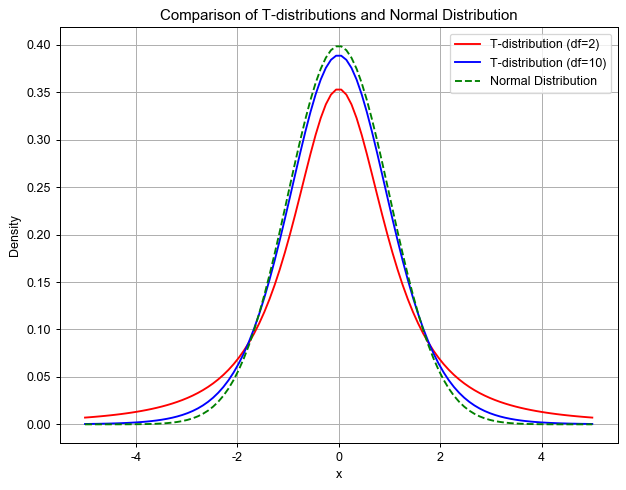

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 生成T分布和标准正态分布的概率密度函数
x = np.linspace(-5, 5, 100)
t_dist_df_2 = stats.t.pdf(x, df=2)  # 自由度为2
t_dist_df_10 = stats.t.pdf(x, df=10)  # 自由度为10
normal_dist = stats.norm.pdf(x)  # 标准正态分布

# 绘图
plt.figure(figsize=(8, 6))
plt.plot(x, t_dist_df_2, label='T-distribution (df=2)', color='red')
plt.plot(x, t_dist_df_10, label='T-distribution (df=10)', color='blue')
plt.plot(x, normal_dist, label='Normal Distribution', color='green', linestyle='--')
plt.title("Comparison of T-distributions and Normal Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

- **自由度为2的T分布**：你可以看到它的尾部更厚，表明较小样本量下T值的波动更大。
- **自由度为10的T分布**：与标准正态分布的形状更加接近。

![原文参考图，当前结果见代码输出](attachments/img_023.png)

### T检验的详细推导过程

T检验的核心思想是通过计算两个样本均值差异的标准化量值，并根据自由度下的T分布确定该差异是否显著。

#### 单样本T检验公式：

当我们有一个样本要与已知总体均值进行比较时，T值的计算公式为：


$$
t = \frac{\bar{X} - \mu_0}{\frac{s}{\sqrt{n}}}
$$


其中：

- $\bar{X}$ 是样本均值
- $\mu_0$ 是总体均值
- $s$ 是样本标准差
- $n$ 是样本量

推导过程：

**1. 均值差异**：首先计算样本均值与总体均值的差异 $\bar{X} - \mu_0$。

**2. 标准化**：由于差异的绝对值没有意义，我们需要对其进行标准化，即除以样本标准差的估计值 $\frac{s}{\sqrt{n}}$。

**3. T分布**：在样本服从正态分布且总体标准差未知的情况下，T值会服从自由度为 $n-1$ 的T分布。

#### 两独立样本T检验公式：

当我们比较两个独立样本的均值时，T值的公式为：


$$
t = \frac{\bar{X_1} - \bar{X_2}}{S_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}
$$


其中：

- $\bar{X_1}$ 和 $\bar{X_2}$ 分别是两组样本的均值
- $n_1$ 和 $n_2$ 是两个样本的样本量
- $S_p$ 是两组样本的合并标准差，计算公式为：


$$
S_p = \sqrt{\frac{(n_1 - 1)S_1^2 + (n_2 - 1)S_2^2}{n_1 + n_2 - 2}}
$$


推导过程：

**1. 均值差异**：首先计算两个样本均值的差异 $\bar{X_1} - \bar{X_2}$。

**2. 标准化差异**：使用合并标准差 $S_p$ 对均值差异进行标准化，合并标准差结合了两个样本的变异性。

**3. 自由度**：根据样本量和样本标准差，计算合并的自由度 $df = n_1 + n_2 - 2$。

### Python实现：T检验和可视化

在实际分析中，T检验常用于小规模样本下的均值比较。以下代码演示了如何使用Python实现T检验，并进行数据可视化。

T统计量: 1.0232558999225763
p值: 0.3104359181654001


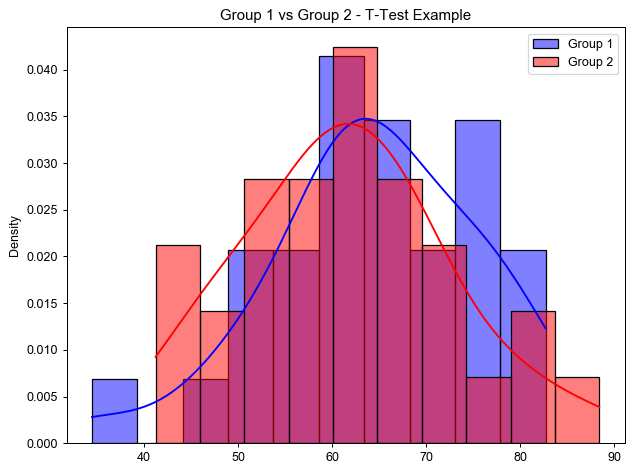

In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 设置随机种子
np.random.seed(0)

# 生成两个正态分布的样本数据
group1 = np.random.normal(60, 10, 30)  # 均值60，标准差10，样本量30
group2 = np.random.normal(65, 12, 30)  # 均值65，标准差12，样本量30

# 进行独立样本T检验
t_stat, p_value = stats.ttest_ind(group1, group2)

print(f"T统计量: {t_stat}")
print(f"p值: {p_value}")

# 可视化两组数据的分布
plt.figure(figsize=(8, 6))
sns.histplot(group1, color="blue", label="Group 1", kde=True, stat="density", bins=10)
sns.histplot(group2, color="red", label="Group 2", kde=True, stat="density", bins=10)
plt.title("Group 1 vs Group 2 - T-Test Example")
plt.legend()
plt.show()

- **数据生成**：生成了两组服从正态分布的样本数据，代表不同组学生的成绩。
- **T检验**：使用 `scipy.stats.ttest_ind` 进行独立样本T检验，输出T统计量和p值。
- **可视化**：绘制了两组数据的分布直方图，叠加了概率密度曲线，可以直观地看到两组数据的分布情况。

![原文参考图，当前结果见代码输出](attachments/img_024.png)

#### 机器学习中的T检验应用

T检验常用于特征选择，尤其是在分类问题中，我们可以通过T检验来确定哪些特征在不同类别之间有显著差异。

In [4]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 加载Iris数据集
data = load_iris()
X = data.data
y = data.target

# 使用ANOVA的F值检验（类似于T检验）进行特征选择
F_values, p_values = f_classif(X, y)

print("各特征的F值:", F_values)
print("各特征的p值:", p_values)

# 根据p值选择显著特征
selected_features = X[:, p_values < 0.05]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(selected_features, y, test_size=0.3, random_state=0)

# 训练逻辑回归模型
model = LogisticRegression()
model.fit(X_train, y_train)

# 预测并计算准确率
y_pred = model.predict(X_test)
print("模型准确率:", accuracy_score(y_test, y_pred))

各特征的F值: [ 119.26450218   49.16004009 1180.16118225  960.0071468 ]
各特征的p值: [1.66966919e-31 4.49201713e-17 2.85677661e-91 4.16944584e-85]
模型准确率: 0.9777777777777777


**1. F检验**：类似于T检验，F检验用于比较多个类别之间特征的方差。根据p值，我们可以选择显著性高的特征用于模型训练。

**2. 逻辑回归模型**：通过选择显著性特征后，使用逻辑回归模型对Iris数据集进行分类，并计算模型准确率。